# 01 · Exploratory Data Analysis

**Task:** predict the sentiment of a comment *toward the drug named in the row*: 0 = positive, 1 = negative, 2 = neutral.
**Metric:** weighted F1.

This notebook explores `train.csv`, describes the inputs of `test.csv` (drug names and text) and turns each finding into a
modelling decision. The test set has no labels and is only described here; nothing is chosen or tuned on it.

Figures are saved to `artifacts/reports/figures/` for the presentation. Plotting helpers live in
`src/drug_sentiment/visualization/`, statistics helpers in `src/drug_sentiment/analysis/eda_stats.py`.

| Section | Question |
|---|---|
| 1 | Is the data clean? |
| 2 | Is the target imbalanced? |
| 3 | Do train and test contain the same drugs? |
| 4 | Does sentiment depend on the drug? |
| 5 | How long are comments, and does length differ by class? |
| 6 | Where in the comment is the drug mentioned? |
| 7 | What happens when one comment covers several drugs? |
| 8 | Which words characterise each class? |
| 9 | Does a sentiment lexicon agree with the labels? |
| 10 | Summary: answers and design decisions |

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import f1_score, roc_auc_score

from drug_sentiment.analysis.eda_stats import add_text_stats, distinctive_terms, label_share, vader_compound
from drug_sentiment.config import get_config
from drug_sentiment.data.ingestion import count_physical_lines, load_raw_data
from drug_sentiment.visualization import eda_plots
from drug_sentiment.visualization.style import LABEL_ORDER, apply_style, save_figure

apply_style()
pd.set_option("display.max_colwidth", 150)

cfg = get_config()
raw = load_raw_data(cfg)
train, test = raw.train.copy(), raw.test.copy()
train["label"] = train[cfg.data.target_col].map(cfg.data.label_names)

[2026-09-15 03:40:58,561] INFO drug_sentiment.data.ingestion:77 - train: 5279 records from 5619 physical lines (multi-line comments)


[2026-09-15 03:40:58,617] INFO drug_sentiment.data.ingestion:77 - test: 2924 records from 3107 physical lines (multi-line comments)


[2026-09-15 03:40:58,636] INFO drug_sentiment.data.ingestion:83 - Raw data validation passed


## 1. Data overview and quality

In [2]:
overview = pd.DataFrame(
    {
        "records": [len(train), len(test)],
        "physical lines": [count_physical_lines(cfg.data.train_path), count_physical_lines(cfg.data.test_path)],
        "columns": [", ".join(raw.train.columns), ", ".join(test.columns)],
    },
    index=["train", "test"],
)
display(overview)
display(raw.train.dtypes.to_frame("dtype"))

,records,physical lines,columns
train,5279,5619,"unique_hash, text, drug, sentiment"
test,2924,3107,"unique_hash, text, drug"


,dtype
unique_hash,str
text,str
drug,str
sentiment,int64


In [3]:
quality = pd.Series(
    {
        "null values (train)": int(raw.train.isna().sum().sum()),
        "null values (test)": int(test.isna().sum().sum()),
        "duplicate unique_hash (train)": int(train["unique_hash"].duplicated().sum()),
        "duplicate (text, drug) pairs (train)": int(train.duplicated(["text", "drug"]).sum()),
        "(text, drug) pairs with conflicting labels": int((train.groupby(["text", "drug"])["sentiment"].nunique() > 1).sum()),
        "unique_hash values shared by train and test": len(set(train["unique_hash"]) & set(test["unique_hash"])),
        "repeated comment texts (train)": int(train["text"].duplicated().sum()),
    },
    name="count",
)
display(quality.to_frame())
train.sample(3, random_state=cfg.seed)[["drug", "label", "text"]]

,count
null values (train),0
null values (test),0
duplicate unique_hash (train),0
"duplicate (text, drug) pairs (train)",0
"(text, drug) pairs with conflicting labels",0
unique_hash values shared by train and test,0
repeated comment texts (train),98


,drug,label,text
8,fingolimod,negative,Why do you think that FIngolimod was such a miserable failure in progressive MS trial in humans (not animals) that was aborted by Biogen? If it is...
1580,cladribine,neutral,Lemtrada is for any form of MS with relapses. Reversal of current damage is seen in anyone with natural neuronal reserve. Reversal becomes evident...
544,stelara,neutral,I wonder if anyone has ever combined two biologics? Humira and Stelara for example.... Can't find any data on that notion. I guess it requires the...


**Findings**
- The files hold **5,279 train and 2,924 test records**. The brief's 5,619 / 3,107 are physical line counts: 340 train and
  183 test comments contain line breaks inside a quoted field. The submission therefore needs 2,924 rows, matching
  `sample_submission.csv`.
- No nulls, no duplicate ids, no duplicate (text, drug) pairs and no conflicting labels.
- 98 comment texts repeat in train, each time with a different drug (section 7).

**Decision:** keep every row; no imputation or de-duplication is needed.

## 2. Target distribution

,rows,share
label,,
negative,837,0.159
neutral,3825,0.725
positive,617,0.117


Imbalance ratio (largest / smallest class): 6.2
Weighted F1 when always predicting 'neutral': 0.609


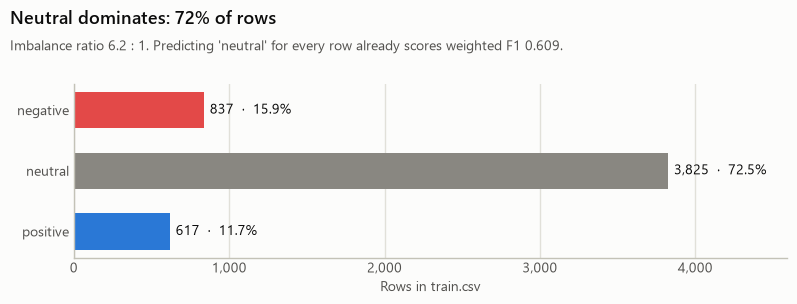

In [4]:
class_table = train["label"].value_counts().reindex(LABEL_ORDER).to_frame("rows")
class_table["share"] = (class_table["rows"] / len(train)).round(3)
imbalance_ratio = class_table["rows"].max() / class_table["rows"].min()
majority_f1 = f1_score(train["sentiment"], np.full(len(train), 2), average="weighted")

display(class_table)
print(f"Imbalance ratio (largest / smallest class): {imbalance_ratio:.1f}")
print(f"Weighted F1 when always predicting 'neutral': {majority_f1:.3f}")

fig = eda_plots.plot_class_distribution(
    train["label"],
    title=f"Neutral dominates: {class_table.loc['neutral', 'share']:.0%} of rows",
    subtitle=f"Imbalance ratio {imbalance_ratio:.1f} : 1. Predicting 'neutral' for every row already scores "
             f"weighted F1 {majority_f1:.3f}.",
)
save_figure(fig, "eda_01_class_distribution")
plt.show()

**Findings**
- Neutral 72.5%, negative 15.9%, positive 11.7%: an imbalance ratio of 6.2 : 1.
- Always predicting neutral already gives **weighted F1 0.609**. Weighted F1 rewards the majority class, so a model can look
  good while missing most positive and negative rows.

**Decisions**
- Treat 0.609 as the floor every model must beat.
- Use stratified cross-validation so every fold keeps these proportions.
- Compare class weighting (and resampling inside the training folds) for the minority classes.
- Report per-class precision, recall and F1, and macro F1, next to weighted F1.

## 3. Drugs in train and test

,value
distinct drugs (train),102
distinct drugs (test),95
train drugs with fewer than 10 rows,53
train drugs with a single row,21
rows covered by the top 10 drugs (train),65.6%
rows covered by the top 10 drugs (test),62.1%
drug names only in test,9
test rows with such a drug,12


,test rows
drug,
afainib,1
alitma,1
duvalumab,2
elotinib,1
etrolizumab,1
flixabi,1
osmertinib,1
risankizumab,2
stellara,2


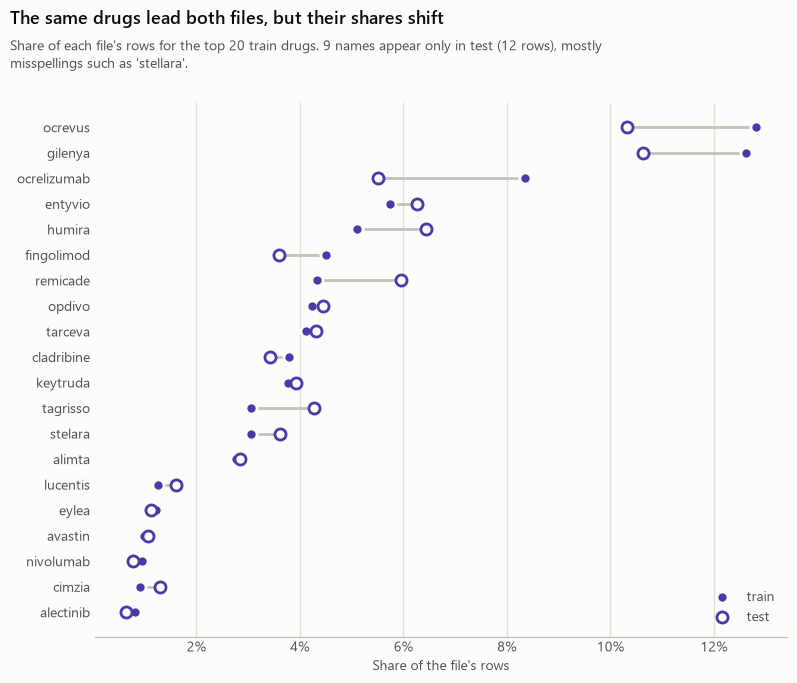

In [5]:
train_counts, test_counts = train["drug"].value_counts(), test["drug"].value_counts()
unseen = sorted(set(test_counts.index) - set(train_counts.index))

drug_summary = pd.Series(
    {
        "distinct drugs (train)": train_counts.size,
        "distinct drugs (test)": test_counts.size,
        "train drugs with fewer than 10 rows": int((train_counts < 10).sum()),
        "train drugs with a single row": int((train_counts == 1).sum()),
        "rows covered by the top 10 drugs (train)": f"{train_counts.head(10).sum() / len(train):.1%}",
        "rows covered by the top 10 drugs (test)": f"{test_counts.head(10).sum() / len(test):.1%}",
        "drug names only in test": len(unseen),
        "test rows with such a drug": int(test_counts[unseen].sum()),
    },
    name="value",
)
display(drug_summary.to_frame())
display(test_counts[unseen].rename("test rows").to_frame())

fig = eda_plots.plot_drug_frequency(
    train["drug"], test["drug"],
    title="The same drugs lead both files, but their shares shift",
    subtitle=f"Share of each file's rows for the top 20 train drugs. {len(unseen)} names appear only in test "
             f"({int(test_counts[unseen].sum())} rows), mostly misspellings such as 'stellara'.",
)
save_figure(fig, "eda_02_drug_frequency")
plt.show()

**Findings**
- 102 drugs in train and 95 in test. The same drugs lead both files (the top 10 cover 66% of train rows and 62% of test
  rows), but some shares shift: ocrelizumab is 8.4% of train vs 5.5% of test, remicade 4.3% vs 6.0%.
- Long tail: 53 train drugs have fewer than 10 rows and 21 have a single row.
- 9 drug names exist only in test (12 rows). Most are misspellings of train drugs: `stellara` (stelara), `osmertinib`
  (osimertinib), `afainib` (afatinib), `elotinib` (erlotinib), `duvalumab` (durvalumab), `alitma` (alimta). Only `flixabi`,
  `etrolizumab` and `risankizumab` are new. Train has misspellings too (`alectnib`, `pemrolizumab`, `nivolumabb`).
- Brand and generic names of the same molecule are separate drugs: gilenya / fingolimod, ocrevus / ocrelizumab,
  tarceva / erlotinib.

**Decisions**
- Find drug mentions with fuzzy matching so misspelt names are still located in the text.
- Add a brand ↔ generic synonym map so a mention of *fingolimod* counts as a mention of *gilenya*.
- Encode drug identity with rare drugs grouped (one-hot with a minimum frequency, or target encoding inside CV).
- Because the drug mix shifts between files, the drug should support the text features rather than dominate them.

## 4. Sentiment by drug

label,negative,neutral,positive,n
drug,,,,
gilenya,0.354,0.530,0.116,666
fingolimod,0.218,0.718,0.063,238
remicade,0.197,0.738,0.066,229
lucentis,0.164,0.672,0.164,67
ocrevus,0.161,0.673,0.166,676
tarceva,0.161,0.761,0.078,218
humira,0.148,0.789,0.063,270
keytruda,0.136,0.754,0.111,199
alimta,0.130,0.795,0.075,146


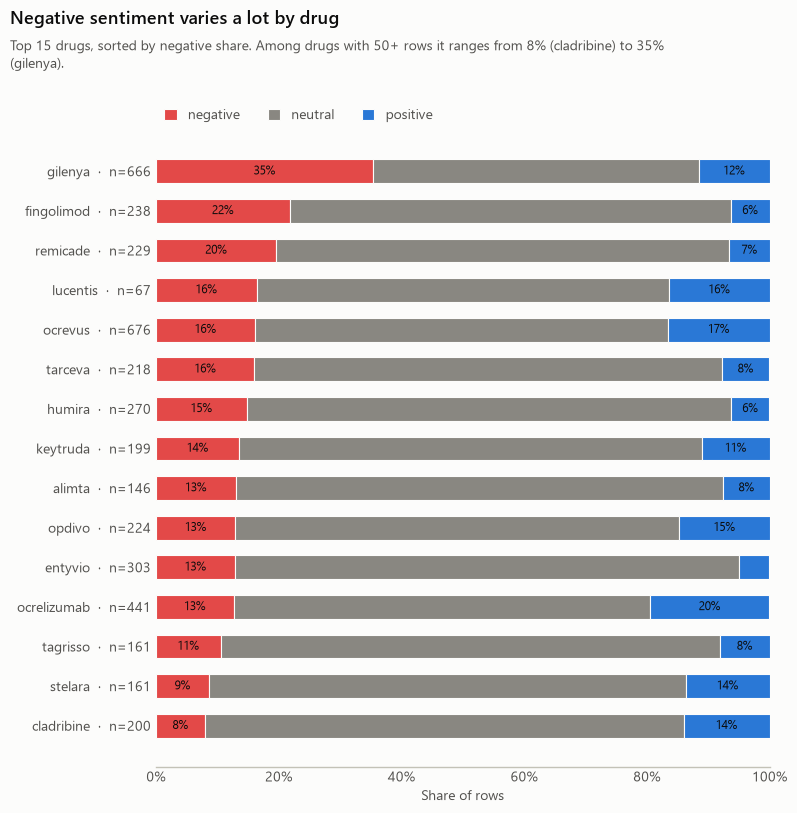

In [6]:
all_drug_share = label_share(train, "drug")
drug_share = all_drug_share.loc[train_counts.head(15).index].sort_values("negative", ascending=False)
display(drug_share.round(3))

frequent = all_drug_share.loc[train_counts[train_counts >= 50].index]
least, most = frequent["negative"].idxmin(), frequent["negative"].idxmax()

fig = eda_plots.plot_label_share(
    drug_share,
    title="Negative sentiment varies a lot by drug",
    subtitle=f"Top 15 drugs, sorted by negative share. Among drugs with 50+ rows it ranges from "
             f"{frequent.loc[least, 'negative']:.0%} ({least}) to {frequent.loc[most, 'negative']:.0%} ({most}).",
)
save_figure(fig, "eda_03_sentiment_by_drug")
plt.show()

**Findings**
- The label mix differs strongly by drug. Among drugs with 50+ rows the negative share ranges from 8% (cladribine) to
  35% (gilenya).
- Even one molecule differs by name: gilenya is 35% negative, fingolimod 22%.

**Decision:** the drug is a useful prior, so drug identity becomes a feature (its encoding is fit inside each CV fold).
The label is still about what the text says, so the drug supports the text features rather than replacing them.

## 5. Comment length

word_count        char_count        
             median   mean     median    mean
label                                        
negative      137.0  249.0      746.0  1425.0
neutral       146.0  367.0      836.0  2255.0
positive      122.0  305.0      702.0  1847.0

Average comment: 341 words (2,076 characters); median 141 words; longest 19,614 words


label,negative,neutral,positive,n
word_count,,,,
Q1 shortest,0.152,0.703,0.145,1320
Q2,0.175,0.715,0.110,1328
Q3,0.174,0.723,0.104,1312
Q4 longest,0.133,0.758,0.109,1319


label,negative,neutral,positive,n
char_count,,,,
"over 5,000 characters",0.094,0.793,0.113,434
"up to 5,000 characters",0.164,0.718,0.117,4845


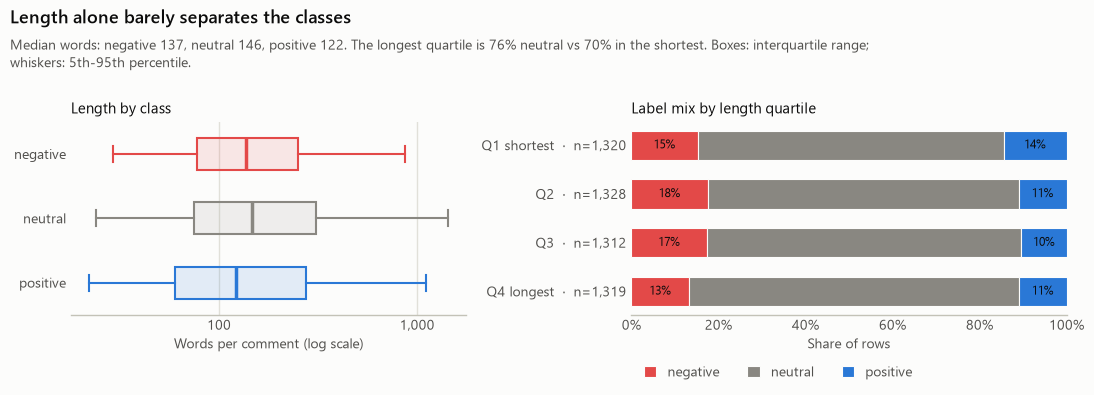

In [7]:
stats = add_text_stats(train)  # length and mention statistics, reused in sections 5-9

length_by_class = stats.groupby("label")[["word_count", "char_count"]].agg(["median", "mean"]).reindex(LABEL_ORDER)
display(length_by_class.round(0))
print(
    f"Average comment: {stats['word_count'].mean():.0f} words ({stats['char_count'].mean():,.0f} characters); "
    f"median {stats['word_count'].median():.0f} words; longest {stats['word_count'].max():,} words"
)

length_quartile = pd.qcut(stats["word_count"], 4, labels=["Q1 shortest", "Q2", "Q3", "Q4 longest"])
quartile_share = label_share(stats, length_quartile)
long_document = (stats["char_count"] > cfg.preprocessing.long_doc_chars).map(
    {False: "up to 5,000 characters", True: "over 5,000 characters"}
)
display(quartile_share.round(3))
display(label_share(stats, long_document).round(3))

median_words = stats.groupby("label")["word_count"].median()
fig = eda_plots.plot_length_by_class(
    {label: stats.loc[stats["label"] == label, "word_count"] for label in LABEL_ORDER},
    quartile_share,
    title="Length alone barely separates the classes",
    subtitle=f"Median words: negative {median_words['negative']:.0f}, neutral {median_words['neutral']:.0f}, "
             f"positive {median_words['positive']:.0f}. The longest quartile is "
             f"{quartile_share.loc['Q4 longest', 'neutral']:.0%} neutral vs "
             f"{quartile_share.loc['Q1 shortest', 'neutral']:.0%} in the shortest. "
             f"Boxes: interquartile range; whiskers: 5th-95th percentile.",
)
save_figure(fig, "eda_04_text_length")
plt.show()

**Findings**
- Average comment: 341 words (2,076 characters); median 141 words, with a long right tail up to 19,614 words.
- Median length is similar across classes (positive 122, negative 137, neutral 146 words), so length alone separates
  the classes poorly.
- Longer texts lean neutral: the longest quartile is 76% neutral vs 70% in the shortest, and the 434 texts over 5,000
  characters (drug labels, articles, trial reports) are 79% neutral and only 9% negative.

**Decisions**
- Add length and a long-document flag as weak supporting features.
- Don't feed whole long documents to the model; crop them around the drug (next section).

## 6. Where is the drug mentioned?

,value
rows where the drug name is found literally,99.8%
first mention: median word,41
first mention: 90th percentile word,268
first mention: 95th percentile word,508
rows whose first mention is after word 380,6.9%


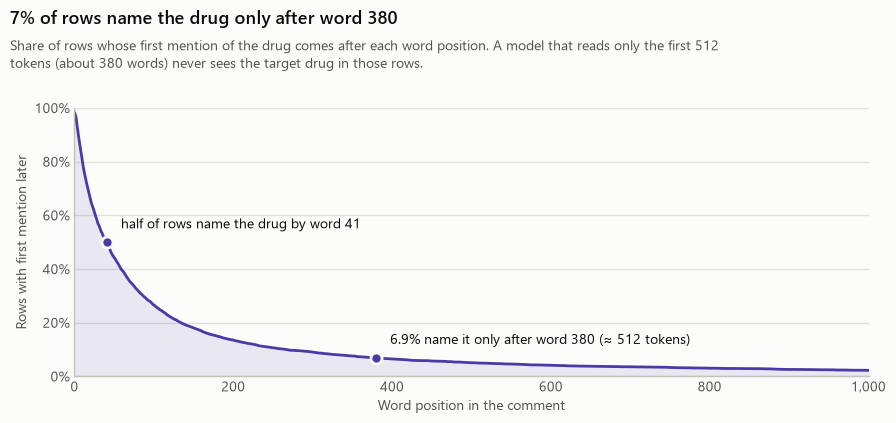

In [8]:
TRANSFORMER_WORD_LIMIT = 380  # about 512 subword tokens at ~1.35 tokens per word

found = stats["first_mention_word"] >= 0
first_word = stats.loc[found, "first_mention_word"]
late = stats["first_mention_word"] > TRANSFORMER_WORD_LIMIT

mention_summary = pd.Series(
    {
        "rows where the drug name is found literally": f"{found.mean():.1%}",
        "first mention: median word": round(first_word.median()),
        "first mention: 90th percentile word": round(first_word.quantile(0.90)),
        "first mention: 95th percentile word": round(first_word.quantile(0.95)),
        f"rows whose first mention is after word {TRANSFORMER_WORD_LIMIT}": f"{late.mean():.1%}",
    },
    name="value",
)
display(mention_summary.to_frame())

fig = eda_plots.plot_first_mention_position(
    stats["first_mention_word"], TRANSFORMER_WORD_LIMIT,
    title=f"{late.mean():.0%} of rows name the drug only after word {TRANSFORMER_WORD_LIMIT}",
    subtitle="Share of rows whose first mention of the drug comes after each word position. A model that reads only "
             "the first 512 tokens (about 380 words) never sees the target drug in those rows.",
)
save_figure(fig, "eda_05_first_mention_position")
plt.show()

**Findings**
- The drug name is found literally in 99.8% of rows. The 11 misses are short fragments of longer comments that don't name it.
- The first mention is at word 41 in the median row, but at word 268 at the 90th percentile and word 508 at the 95th.
- **6.9% of rows name the drug for the first time after word 380** (about 512 subword tokens). A model that reads only the
  first 512 tokens would never see the target drug in these rows.

**Decision:** build the model input from a **window of sentences around each mention of the target drug** instead of the
start of the comment.

label,negative,neutral,positive,n
mention_count,,,,
0 (name not found),0.182,0.636,0.182,11
1 mention,0.141,0.760,0.099,3476
2 mentions,0.185,0.681,0.134,946
3 mentions,0.158,0.664,0.178,354
4 mentions,0.255,0.585,0.160,188
5+ mentions,0.217,0.618,0.164,304


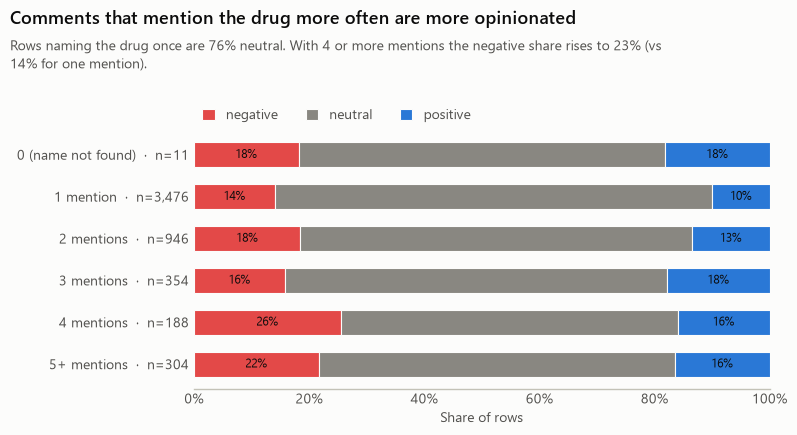

In [9]:
mention_group = stats["mention_count"].clip(upper=5).map(
    lambda n: "0 (name not found)" if n == 0 else "5+ mentions" if n == 5 else f"{n} mention" + ("s" if n > 1 else "")
)
mention_share = label_share(stats, mention_group)
display(mention_share.round(3))

negative_one = stats.loc[stats["mention_count"] == 1, "label"].eq("negative").mean()
negative_many = stats.loc[stats["mention_count"] >= 4, "label"].eq("negative").mean()
fig = eda_plots.plot_label_share(
    mention_share,
    title="Comments that mention the drug more often are more opinionated",
    subtitle=f"Rows naming the drug once are {mention_share.loc['1 mention', 'neutral']:.0%} neutral. With 4 or more "
             f"mentions the negative share rises to {negative_many:.0%} (vs {negative_one:.0%} for one mention).",
)
save_figure(fig, "eda_06_mention_count")
plt.show()

**Findings**
- 66% of rows name the drug once, and those rows are 76% neutral.
- Rows naming the drug 4 or more times are more opinionated: the negative share rises to 23% (vs 14% for a single mention).

**Decision:** add the mention count and the position of the first mention as features.

## 7. One comment, several drugs

label,negative,neutral,positive,n
drugs_sharing_text,,,,
comment about one drug,0.164,0.715,0.121,5093
comment shared by several drugs,0.000,1.000,0.000,186


Train rows whose comment is repeated for another drug: 186 (88 comments)
Test rows whose comment also appears in train: 843 of 2,924 (29%)


,drug,label
2249,stelara,neutral
4622,remicade,neutral


Hey there. This is my first post on any forum. I was diagnosed with Crohns January 2017 and have been on Remicade and Humira, both of which my body developed antibodies to within a few months. I just had an ileocolic resection at the end of March and just started my first dose of Stelara today. Has anybody experienced any strange side effects with Stelara or how well is it working? It makes me nervous to have only had Crohns for less than two years and already have gone through all of this. I really hope this one helps me.


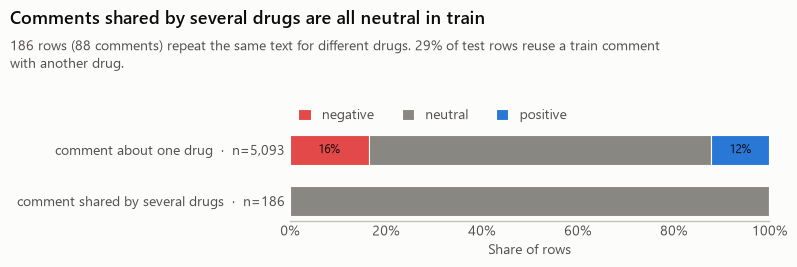

In [10]:
shared = stats["drugs_sharing_text"] > 1
shared_share = label_share(stats, shared.map({False: "comment about one drug", True: "comment shared by several drugs"}))
display(shared_share.round(3))

test_reuse = test["text"].isin(set(train["text"]))
print(f"Train rows whose comment is repeated for another drug: {shared.sum()} ({stats.loc[shared, 'text'].nunique()} comments)")
print(f"Test rows whose comment also appears in train: {test_reuse.sum():,} of {len(test):,} ({test_reuse.mean():.0%})")

example_text = stats.loc[shared].sort_values("char_count")["text"].iloc[10]
display(stats.loc[stats["text"] == example_text, ["drug", "label"]])
print(example_text[:600])

fig = eda_plots.plot_label_share(
    shared_share,
    title="Comments shared by several drugs are all neutral in train",
    subtitle=f"{shared.sum()} rows ({stats.loc[shared, 'text'].nunique()} comments) repeat the same text for different drugs. "
             f"{test_reuse.mean():.0%} of test rows reuse a train comment with another drug.",
)
save_figure(fig, "eda_07_shared_comments")
plt.show()

**Findings**
- 186 train rows (88 comments) reuse the same comment for different drugs, and every one of them is neutral. The brief
  warns that labels *can* differ per drug for the same comment; this training sample simply contains no such case.
- 843 test rows (29%) reuse a comment that appears in train, always paired with a different drug.

**Decisions**
- Validate with **StratifiedGroupKFold grouped by comment text**, so one comment never sits in both the training and the
  validation fold. Otherwise validation rewards memorising a comment's label instead of reading it for the given drug.
- Mask drug names in the model input (`targetdrug` / `otherdrug`) and count how many other drugs a comment mentions, so
  the model knows which drug the row is about.

## 8. Vocabulary per class

Words are counted in the drug's own sentences rather than the whole comment. Each word is scored by how much more often it
appears in documents of one class than in the other classes (log ratio of document rates, add-one smoothed, words in at
least 15 documents). Drug names and stop words are removed; negations such as *not* and *never* are kept.

Drug sentences: median 26 words, 20% of the comment in the median row


label,negative,neutral,positive
rank,,,
1,headaches,asas,glad
2,rebound,biosimilar,breakthrough
3,breathing,tarcrva,granted
4,diarrhea,eligible,oratorio
5,worse,multicenter,annualized
6,infections,solution,improvements
7,fatigue,adenocarcinoma,love
8,nausea,criteria,news
9,unfortunately,notes,showing


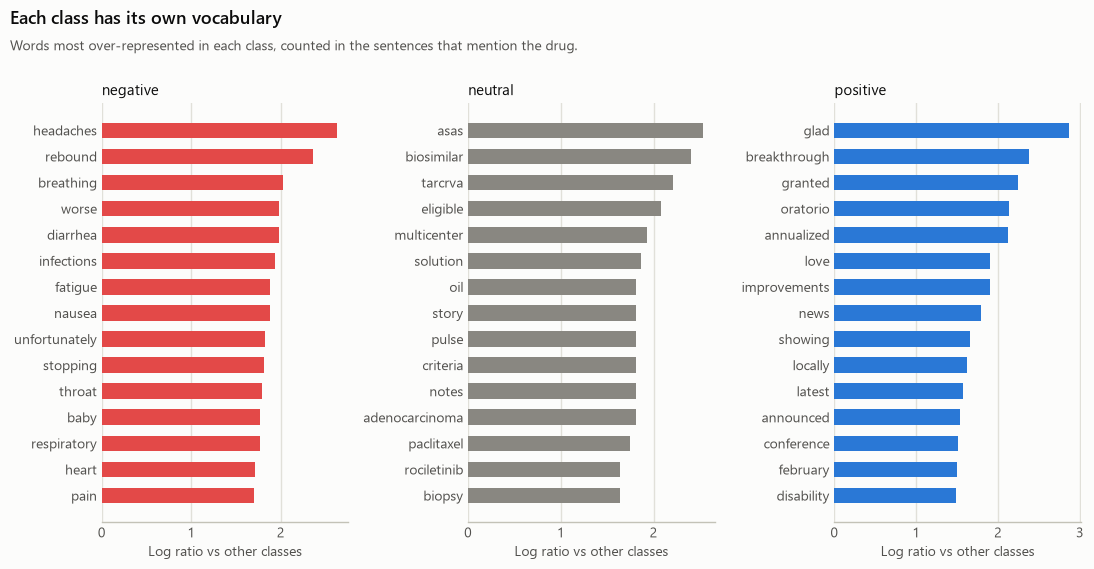

In [11]:
window_words = stats["drug_sentences"].str.split().str.len()
print(
    f"Drug sentences: median {window_words.median():.0f} words, "
    f"{(window_words / stats['word_count']).median():.0%} of the comment in the median row"
)

drug_tokens = {token for name in train["drug"].str.lower() for token in re.split(r"[\s\-]+", name)}
terms = distinctive_terms(stats["drug_sentences"], stats["label"], exclude=drug_tokens, top_n=15)
terms_table = terms.assign(rank=terms.groupby("label").cumcount() + 1).pivot(index="rank", columns="label", values="term")
display(terms_table[list(LABEL_ORDER)])

fig = eda_plots.plot_distinctive_terms(
    terms,
    title="Each class has its own vocabulary",
    subtitle="Words most over-represented in each class, counted in the sentences that mention the drug.",
)
save_figure(fig, "eda_08_distinctive_words")
plt.show()

**Findings**
- **Negative** sentences describe side effects and worsening: headaches, rebound, diarrhea, infections, fatigue, nausea,
  worse, pain, unfortunately.
- **Positive** sentences mix patient relief (glad, love, improvements) with good news: breakthrough, granted, announced,
  news, latest (approvals and trial results).
- **Neutral** text is clinical and informational: eligible, multicenter, criteria, biopsy, biosimilar, adenocarcinoma. It
  also contains drug names missing from the train list (paclitaxel, rociletinib) and misspellings (`tarcrva`).

**Decisions**
- Use word 1–2-gram TF-IDF on the drug window, with negations removed from the stop-word list.
- Add character n-grams, which still match misspellings such as *tarcrva*.

## 9. Lexicon sentiment: full comment vs drug sentences

VADER is a rule-based sentiment lexicon: it learns nothing from the data, so it cannot leak labels. Scoring every full
comment takes about 1.5 minutes because some comments are very long.

vader_full        vader_drug_sentences       
               mean median                 mean median
label                                                 
negative      0.073  0.209               -0.097  0.000
neutral       0.286  0.584                0.106  0.000
positive      0.500  0.825                0.338  0.422

Positive-vs-negative AUC: full comment 0.664, drug sentences 0.748


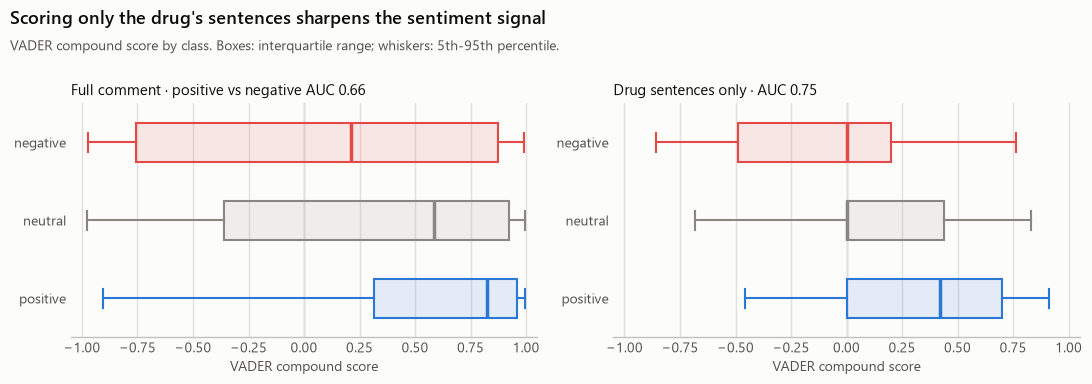

In [12]:
stats["vader_full"] = vader_compound(stats["text"])
stats["vader_drug_sentences"] = vader_compound(stats["drug_sentences"])

vader_table = stats.groupby("label")[["vader_full", "vader_drug_sentences"]].agg(["mean", "median"]).reindex(LABEL_ORDER)
display(vader_table.round(3))

polar = stats[stats["label"] != "neutral"]
auc_full = roc_auc_score(polar["label"] == "positive", polar["vader_full"])
auc_window = roc_auc_score(polar["label"] == "positive", polar["vader_drug_sentences"])
print(f"Positive-vs-negative AUC: full comment {auc_full:.3f}, drug sentences {auc_window:.3f}")

by_class = lambda column: {label: stats.loc[stats["label"] == label, column] for label in LABEL_ORDER}
fig = eda_plots.plot_vader_by_class(
    by_class("vader_full"), by_class("vader_drug_sentences"),
    panel_titles=(f"Full comment · positive vs negative AUC {auc_full:.2f}",
                  f"Drug sentences only · AUC {auc_window:.2f}"),
    title="Scoring only the drug's sentences sharpens the sentiment signal",
    subtitle="VADER compound score by class. Boxes: interquartile range; whiskers: 5th-95th percentile.",
)
save_figure(fig, "eda_09_vader_full_vs_drug_sentences")
plt.show()

**Findings**
- Scored on the full comment, VADER separates positive from negative rows poorly (AUC 0.66), and neutral comments look
  mildly positive (mean 0.29).
- Scored on the drug's sentences only, separation improves to **AUC 0.75**.
- The median drug-sentence score is exactly 0 for negative and neutral rows: the lexicon misses medical cues such as
  *rebound* or *infections*.

**Decisions**
- Use VADER scores of the drug window as extra features, not as a model on their own.
- This is independent evidence for drug-centred windows: the same scorer improves just by reading the right sentences.

## 10. Summary

### Answers to the brief's key questions

| Question | Answer |
|---|---|
| Is the dataset class-imbalanced? | Yes: neutral 72.5%, negative 15.9%, positive 11.7% (6.2 : 1). Always predicting neutral scores weighted F1 0.609. |
| Are there drugs only in test? | 9 names (12 rows), mostly misspellings of train drugs (`stellara`, `osmertinib`, `afainib`); `flixabi`, `etrolizumab` and `risankizumab` are new. |
| What is the average comment length? | 341 words / 2,076 characters (median 141 words), with a long tail up to 19,614 words. |
| Does length differ by sentiment? | Only slightly: medians are 122–146 words. Very long documents lean neutral (79% of texts over 5,000 characters). |

### EDA findings → design decisions

| Finding | Decision | Phase |
|---|---|---|
| 72.5% neutral; weighted F1 floor 0.609 | Stratified CV, class weights, per-class and macro F1 reporting | 3, 5 |
| 6.9% of rows name the drug after word 380 | Sentence windows around the target drug | 3 |
| 88 comments cover several drugs; 29% of test rows reuse a train comment | Mask target / other drugs; CV folds grouped by comment text | 3 |
| Misspelt and brand / generic drug names | Fuzzy drug matching and a synonym map | 3 |
| Negative share varies from 8% to 35% by drug | Drug identity feature, encoded inside CV | 5 |
| Mention count and length shift the label mix | Handcrafted features: mention count, first-mention position, length, long-document flag | 3 |
| Side-effect vs news vs clinical vocabulary; misspellings | Word 1–2-gram and character n-gram TF-IDF, negations kept | 5 |
| VADER AUC 0.66 on full comments vs 0.75 on drug sentences | Lexicon scores computed on the drug window | 3 |